In [ ]:
import os
import math
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple

import torch
from torch import nn
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------

@dataclass
class Config:
    model_name: str = "meta-llama/Meta-Llama-3-8B-Instruct"  # or pretrained base[web:27][web:31][web:34]
    cinepile_name: str = "tomg-group-umd/cinepile"           # HF dataset id[web:32][web:40]
    split: str = "test"                                      # or "validation"
    num_examples: int = 128                                  # for debugging; scale up later
    max_seq_len: int = 2048
    device: str = "cuda"
    dtype: torch.dtype = torch.bfloat16

    # corruption settings (simple label-shuffle corruption a la MCQ work[web:8][web:33])
    corruption: str = "shuffle_options"

cfg = Config()

os.makedirs("results_roles_of_components", exist_ok=True)

# ------------------------------------------------------------
# Load model + tokenizer
# ------------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
# ensure we have a padding token (Llama typically uses eos as pad)[web:34]
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name,
    torch_dtype=cfg.dtype,
    device_map="auto"
)
model.eval()

# number of layers for convenience
num_layers = model.config.num_hidden_layers  # should be 32 for Llama-3-8B[web:34]

# ------------------------------------------------------------
# CinePile text-only MCQ formatting
# ------------------------------------------------------------

def format_cinepile_example(ex):
    """
    Build a text-only MCQ prompt:
    [movie_scene/subtitles text]
    Question: ...
    A) ...
    B) ...
    C) ...
    D) ...
    Answer:
    where the model is expected to output one of A/B/C/D.[web:32][web:40]
    """
    scene_text = ex.get("movie_scene") or ex.get("subtitles") or ""
    question = ex["question"]
    choices = ex["choices"]  # list of 5; you may reduce to 4 if desired[web:32]
    # here assume 4 options; adapt if you want 5
    option_labels = ["A", "B", "C", "D"]
    choices = choices[:4]
    lines = []
    if scene_text:
        lines.append(f"Scene: {scene_text}")
    lines.append(f"Question: {question}")
    for lab, ch in zip(option_labels, choices):
        lines.append(f"{lab}) {ch}")
    lines.append("Answer:")  # we will look at logits for " A"/" B"/" C"/" D"
    prompt = "\n".join(lines)
    answer_key_pos = ex["answer_key_position"]
    # Map to A/B/C/D; if answer index >=4, just clamp for demo
    correct_idx = min(answer_key_pos, 3)
    correct_label = option_labels[correct_idx]
    return prompt, correct_label, option_labels

dataset = load_dataset(cfg.cinepile_name)[cfg.split]  # requires HF login / access[web:32]
dataset = dataset.select(range(min(cfg.num_examples, len(dataset))))

# ------------------------------------------------------------
# Prompt corruption (label shuffle)
# ------------------------------------------------------------

def corrupt_prompt_shuffle_options(prompt: str, correct_label: str, option_labels: List[str]) -> Tuple[str, Dict[str, str]]:
    """
    Shuffle mapping between textual labels and logical labels, to break correspondence,
    similar to label-mapping corruption in the paper.[web:8][web:33]
    Returns corrupted_prompt, mapping from original label->new label.
    """
    import random
    shuffled = option_labels.copy()
    random.shuffle(shuffled)
    mapping = {orig: new for orig, new in zip(option_labels, shuffled)}
    # replace "A)" etc with mapped labels
    corrupted_lines = []
    for line in prompt.splitlines():
        for lab in option_labels:
            token = f"{lab})"
            if token in line:
                line = line.replace(token, f"{mapping[lab]})")
        corrupted_lines.append(line)
    corrupted_prompt = "\n".join(corrupted_lines)
    return corrupted_prompt, mapping

# ------------------------------------------------------------
# Hooks and patching helpers
# ------------------------------------------------------------

class ActivationCache:
    """
    Stores per-layer activations: residual_in, attn_out, mlp_out, residual_out
    for a single forward pass (clean or corrupted).
    """
    def __init__(self, num_layers: int):
        self.num_layers = num_layers
        self.reset()

    def reset(self):
        self.residual_in = [None] * self.num_layers
        self.attn_out = [None] * self.num_layers
        self.mlp_out = [None] * self.num_layers
        self.residual_out = [None] * self.num_layers

def register_hooks(model: nn.Module, cache: ActivationCache, patch_source_cache: Optional[ActivationCache] = None,
                   patch_layer: Optional[int] = None,
                   patch_component: Optional[str] = None):
    """
    Register hooks:
    - If patch_source_cache is None: we only record activations into `cache`.
    - If patch_source_cache is not None: we also optionally overwrite activations
      at `patch_layer` and `patch_component` using values from patch_source_cache.
    patch_component in {None, "residual", "attn", "mlp"}; when None, patch residual stream.
    """
    hooks = []

    # Llama 3 blocks live in model.model.layers in HF[web:34]
    def make_block_hook(layer_idx):
        def forward_hook(block, inputs, output):
            # For HF Llama, block.forward returns hidden_states only (residual_out).[web:34]
            # We must intercept inside attention/mlp submodules instead; this hook will
            # only see final residual_out. We store it, and for residual_in we take inputs[0].
            x_in = inputs[0]  # residual_in
            x_out = output    # residual_out

            cache.residual_in[layer_idx] = x_in.detach()
            cache.residual_out[layer_idx] = x_out.detach()

            # If patching residual stream at this layer
            if (patch_source_cache is not None) and (patch_layer == layer_idx) and (patch_component in [None, "residual"]):
                # Replace x_in with clean residual_in before rest of block.
                # However, at this level, the block has already run, so for true residual
                # patch you want hooks *inside* the block. We accept approximate residual_out
                # patching here for simplicity: swap output.
                with torch.no_grad():
                    x_out = patch_source_cache.residual_out[layer_idx]
                return x_out
            return x_out
        return forward_hook

    # attention and mlp submodules; names follow HF Llama3 implementation[web:34][web:37]
    def make_attn_hook(layer_idx):
        def attn_forward_hook(module, inputs, output):
            # output is attention_out; we store it and optionally patch it
            cache.attn_out[layer_idx] = output.detach()
            if (patch_source_cache is not None) and (patch_layer == layer_idx) and (patch_component == "attn"):
                with torch.no_grad():
                    return patch_source_cache.attn_out[layer_idx]
            return output
        return attn_forward_hook

    def make_mlp_hook(layer_idx):
        def mlp_forward_hook(module, inputs, output):
            cache.mlp_out[layer_idx] = output.detach()
            if (patch_source_cache is not None) and (patch_layer == layer_idx) and (patch_component == "mlp"):
                with torch.no_grad():
                    return patch_source_cache.mlp_out[layer_idx]
            return output
        return mlp_forward_hook

    for i, block in enumerate(model.model.layers):
        hooks.append(block.register_forward_hook(make_block_hook(i)))
        # attention submodule
        if hasattr(block, "self_attn"):
            hooks.append(block.self_attn.register_forward_hook(make_attn_hook(i)))
        elif hasattr(block, "attention"):
            hooks.append(block.attention.register_forward_hook(make_attn_hook(i)))
        # mlp submodule
        if hasattr(block, "mlp"):
            hooks.append(block.mlp.register_forward_hook(make_mlp_hook(i)))

    return hooks

def remove_hooks(hooks):
    for h in hooks:
        h.remove()

# ------------------------------------------------------------
# Utility: run model with optional patching, get logits of labels
# ------------------------------------------------------------

def get_label_token_ids(option_labels: List[str]) -> Dict[str, int]:
    """
    Map "A","B","C","D" to token ids.
    You might want to ensure they are single tokens in your tokenizer; if not,
    consider using " A" etc and adjust prompts accordingly.[web:34]
    """
    mapping = {}
    for lab in option_labels:
        # prepend space to match typical BPE/BPE-like behavior
        tok = tokenizer(" " + lab, add_special_tokens=False)
        assert len(tok.input_ids) == 1, f"Label {lab} not single-token: {tok.input_ids}"
        mapping[lab] = tok.input_ids[0]
    return mapping

label_token_ids = get_label_token_ids(["A", "B", "C", "D"])

@torch.no_grad()
def forward_with_cache(text: str, cache: ActivationCache) -> torch.Tensor:
    """
    Run one example through model while logging activations into `cache`.
    Returns logits (1, seq_len, vocab).
    """
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=False,
        truncation=True,
        max_length=cfg.max_seq_len
    ).to(cfg.device)
    hooks = register_hooks(model, cache)
    outputs = model(**inputs)
    remove_hooks(hooks)
    logits = outputs.logits  # [1, seq_len, vocab]
    return logits, inputs

def get_answer_position(input_ids: torch.Tensor) -> int:
    """
    Find index of "Answer:" and take the next position as the answer-token slot.
    """
    answer_str = "Answer:"
    ans_ids = tokenizer(answer_str, add_special_tokens=False).input_ids
    ids = input_ids[0].tolist()
    for i in range(len(ids) - len(ans_ids)):
        if ids[i: i + len(ans_ids)] == ans_ids:
            return i + len(ans_ids)
    # fallback: last token
    return len(ids) - 1

@torch.no_grad()
def forward_with_patching(text: str,
                          patch_source_cache: ActivationCache,
                          patch_layer: int,
                          patch_component: Optional[str]) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Run model with patching at given layer/component, using activations
    from patch_source_cache (clean run).
    Returns logits and input object.
    """
    cache = ActivationCache(num_layers)
    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=False,
        truncation=True,
        max_length=cfg.max_seq_len
    ).to(cfg.device)
    hooks = register_hooks(
        model,
        cache,
        patch_source_cache=patch_source_cache,
        patch_layer=patch_layer,
        patch_component=patch_component
    )
    outputs = model(**inputs)
    remove_hooks(hooks)
    logits = outputs.logits
    return logits, inputs

def extract_label_logits(logits: torch.Tensor,
                         input_ids: torch.Tensor,
                         option_labels: List[str]) -> Dict[str, float]:
    """
    Extract logits for each option label at the answer position.
    """
    pos = get_answer_position(input_ids)
    last_logits = logits[0, pos, :]  # [vocab]
    out = {}
    for lab in option_labels:
        tid = label_token_ids[lab]
        out[lab] = last_logits[tid].item()
    return out

# ------------------------------------------------------------
# Main experiment loop: roles of layer components
# ------------------------------------------------------------

import csv

layer_contrib_residual = [0.0 for _ in range(num_layers)]
layer_contrib_attn = [0.0 for _ in range(num_layers)]
layer_contrib_mlp = [0.0 for _ in range(num_layers)]
layer_counts = [0 for _ in range(num_layers)]

# also store baseline clean and corrupted diff for reference
baseline_diffs = []

for idx, ex in enumerate(dataset):
    prompt_clean, correct_label, option_labels = format_cinepile_example(ex)
    if cfg.corruption == "shuffle_options":
        prompt_corrupt, label_mapping = corrupt_prompt_shuffle_options(prompt_clean, correct_label, option_labels)
    else:
        raise NotImplementedError

    # clean run
    clean_cache = ActivationCache(num_layers)
    clean_logits, clean_inputs = forward_with_cache(prompt_clean, clean_cache)
    clean_label_logits = extract_label_logits(clean_logits, clean_inputs.input_ids, option_labels)
    clean_correct_logit = clean_label_logits[correct_label]

    # corrupted run
    corrupt_cache = ActivationCache(num_layers)
    corrupt_logits, corrupt_inputs = forward_with_cache(prompt_corrupt, corrupt_cache)
    corrupt_label_logits = extract_label_logits(corrupt_logits, corrupt_inputs.input_ids, option_labels)
    corrupt_correct_logit = corrupt_label_logits[correct_label]

    baseline_diff = clean_correct_logit - corrupt_correct_logit
    baseline_diffs.append(baseline_diff)

    # skip if model already fails badly? (optional filter)
    # if baseline_diff < 0: continue

    for layer in range(num_layers):
        # residual/whole-layer patch: use residual_out swap (approximation)
        patched_logits_res, patched_inputs_res = forward_with_patching(
            prompt_corrupt, clean_cache, patch_layer=layer, patch_component=None
        )
        patched_label_logits_res = extract_label_logits(patched_logits_res, patched_inputs_res.input_ids, option_labels)
        patched_correct_logit_res = patched_label_logits_res[correct_label]
        contrib_res = patched_correct_logit_res - corrupt_correct_logit

        # attention-only patch
        patched_logits_attn, patched_inputs_attn = forward_with_patching(
            prompt_corrupt, clean_cache, patch_layer=layer, patch_component="attn"
        )
        patched_label_logits_attn = extract_label_logits(patched_logits_attn, patched_inputs_attn.input_ids, option_labels)
        patched_correct_logit_attn = patched_label_logits_attn[correct_label]
        contrib_attn = patched_correct_logit_attn - corrupt_correct_logit

        # mlp-only patch
        patched_logits_mlp, patched_inputs_mlp = forward_with_patching(
            prompt_corrupt, clean_cache, patch_layer=layer, patch_component="mlp"
        )
        patched_label_logits_mlp = extract_label_logits(patched_logits_mlp, patched_inputs_mlp.input_ids, option_labels)
        patched_correct_logit_mlp = patched_label_logits_mlp[correct_label]
        contrib_mlp = patched_correct_logit_mlp - corrupt_correct_logit

        layer_contrib_residual[layer] += contrib_res
        layer_contrib_attn[layer] += contrib_attn
        layer_contrib_mlp[layer] += contrib_mlp
        layer_counts[layer] += 1

    print(f"[{idx+1}/{len(dataset)}] baseline_diff={baseline_diff:.3f}")

# ------------------------------------------------------------
# Save results for visualization
# ------------------------------------------------------------

out_path = os.path.join("results_roles_of_components", "layer_component_roles.csv")
with open(out_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["layer", "avg_contrib_residual", "avg_contrib_attn", "avg_contrib_mlp", "count"])
    for layer in range(num_layers):
        if layer_counts[layer] > 0:
            writer.writerow([
                layer,
                layer_contrib_residual[layer] / layer_counts[layer],
                layer_contrib_attn[layer] / layer_counts[layer],
                layer_contrib_mlp[layer] / layer_counts[layer],
                layer_counts[layer],
            ])

print("Saved layer/component roles to:", out_path)


In [ ]:
import os
import math
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

out_dir = "results_roles_of_components_fake"
os.makedirs(out_dir, exist_ok=True)
csv_path = os.path.join(out_dir, "layer_component_roles_fake.csv")

# ------------------------------------------------------------
# Generate fake data (32 layers)
# ------------------------------------------------------------

num_layers = 32
layers = list(range(num_layers))

# Fake pattern:
# - attention: strong bump in middle layers (decision band)
# - mlp: smaller, broader contribution in later layers
# - residual: roughly sum plus noise
attn_vals = []
mlp_vals = []
residual_vals = []
counts = []

for layer in layers:
    # normalized layer index in [0, 1]
    x = layer / (num_layers - 1)

    # attention: Gaussian bump centered around middle (x ~ 0.6)
    attn = math.exp(-0.5 * ((x - 0.6) / 0.12) ** 2) * 0.8
    attn += random.gauss(0, 0.03)

    # mlp: broader bump in later layers
    mlp = math.exp(-0.5 * ((x - 0.8) / 0.2) ** 2) * 0.4
    mlp += random.gauss(0, 0.02)

    # residual ~ sum of both + noise
    residual = attn + mlp + random.gauss(0, 0.05)

    attn_vals.append(attn)
    mlp_vals.append(mlp)
    residual_vals.append(residual)
    counts.append(100)  # pretend 100 examples per layer

df = pd.DataFrame({
    "layer": layers,
    "avg_contrib_residual": residual_vals,
    "avg_contrib_attn": attn_vals,
    "avg_contrib_mlp": mlp_vals,
    "count": counts,
})

df.to_csv(csv_path, index=False)
print("Saved fake CSV to:", csv_path)

# ------------------------------------------------------------
# Plotting (same style as before)
# ------------------------------------------------------------

sns.set_theme(style="whitegrid", context="talk")

# normalize
max_abs = max(
    df["avg_contrib_residual"].abs().max(),
    df["avg_contrib_attn"].abs().max(),
    df["avg_contrib_mlp"].abs().max(),
)
df["residual_norm"] = df["avg_contrib_residual"] / max_abs
df["attn_norm"] = df["avg_contrib_attn"] / max_abs
df["mlp_norm"] = df["avg_contrib_mlp"] / max_abs

# Line plot
plt.figure(figsize=(10, 6))
plt.plot(df["layer"], df["attn_norm"], label="Attention", marker="o")
plt.plot(df["layer"], df["mlp_norm"], label="MLP", marker="s")
plt.plot(df["layer"], df["residual_norm"], label="Whole layer (residual)", linestyle="--", alpha=0.7)
plt.xlabel("Layer index")
plt.ylabel("Normalized contribution (fake)")
plt.title("FAKE Roles of Layer Components (for visualization debug)")
plt.legend()
plt.tight_layout()
line_plot_path = os.path.join(out_dir, "layer_component_roles_line_fake.png")
plt.savefig(line_plot_path, dpi=200)
plt.close()
print("Saved fake line plot to:", line_plot_path)

# Stacked bar
df["total_pos"] = (
    df["avg_contrib_attn"].clip(lower=0) +
    df["avg_contrib_mlp"].clip(lower=0)
)
eps = 1e-8
df["attn_frac"] = df["avg_contrib_attn"].clip(lower=0) / (df["total_pos"] + eps)
df["mlp_frac"] = df["avg_contrib_mlp"].clip(lower=0) / (df["total_pos"] + eps)

plt.figure(figsize=(12, 6))
plt.bar(df["layer"], df["attn_frac"], label="Attention", color="#1f77b4")
plt.bar(df["layer"], df["mlp_frac"], bottom=df["attn_frac"], label="MLP", color="#ff7f0e")
plt.xlabel("Layer index")
plt.ylabel("Fraction of positive contribution (fake)")
plt.title("FAKE Relative Attention vs MLP Contributions per Layer")
plt.legend()
plt.tight_layout()
stack_plot_path = os.path.join(out_dir, "layer_component_roles_stacked_fake.png")
plt.savefig(stack_plot_path, dpi=200)
plt.close()
print("Saved fake stacked bar plot to:", stack_plot_path)


Saved fake CSV to: results_roles_of_components_fake/layer_component_roles_fake.csv
Saved fake line plot to: results_roles_of_components_fake/layer_component_roles_line_fake.png
Saved fake stacked bar plot to: results_roles_of_components_fake/layer_component_roles_stacked_fake.png


In [ ]:
# !pip uninstall -y accelerate
!pip install --no-cache-dir -U transformers datasets bitsandbytes
!pip install 'accelerate>=1.1.0

/bin/bash: -c: line 1: unexpected EOF while looking for matching `''
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [ ]:
# -*- coding: utf-8 -*-
"""
Llama-3.1-8B on CinePile (text-only) + Roles of Layer Components visualization
Single-sample activation patching demo (Colab A100 friendly)
"""

import os
import gc
import math
import random
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Tuple

import torch
from torch import nn
import pandas as pd
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Config
# ============================================================

@dataclass
class ExperimentConfig:
    dataset_name: str          = "tomg-group-umd/cinepile"
    dataset_split: str         = "test"
    max_samples: Optional[int] = 100         # 只跑 100 个样本

    max_scene_length: int      = 500       # 截短 scene，减负
    max_input_tokens: int      = 1024      # 截短上下文

    # Llama-3.1-8B
    llama_model_id: str        = "meta-llama/Llama-3.1-8B-Instruct"

    load_in_4bit: bool         = True
    bnb_4bit_quant_type: str   = "nf4"
    bnb_4bit_compute_dtype: torch.dtype = torch.bfloat16

    # output
    out_dir: str               = "results_llama31_roles"
    csv_layer_roles: str       = "layer_component_roles_single.csv"

    # corruption
    corruption: str            = "shuffle_options"

cfg = ExperimentConfig()
os.makedirs(cfg.out_dir, exist_ok=True)

# ============================================================
# 2. CinePile dataset helper (answer_key → A~E)
# ============================================================

class CinePileDataset:
    LETTERS = ['A', 'B', 'C', 'D', 'E']

    def __init__(self, config: ExperimentConfig):
        self.config = config
        self.data   = self._load()

    @classmethod
    def _answer_text_to_letter(cls, answer_text: str, choices: list) -> str:
        # 精确匹配
        for i, choice in enumerate(choices):
            if answer_text == choice:
                return cls.LETTERS[i]
        # strip 后匹配
        answer_stripped = answer_text.strip()
        for i, choice in enumerate(choices):
            if answer_stripped == choice.strip():
                return cls.LETTERS[i]
        # 包含匹配
        for i, choice in enumerate(choices):
            if answer_stripped in choice or choice.strip() in answer_stripped:
                return cls.LETTERS[i]
        print("[Warning] Cannot match answer_key to choices.")
        print("  answer_key :", repr(answer_text))
        print("  choices    :", choices)
        return 'A'

    @staticmethod
    def _normalize_hard_split(raw) -> bool:
        if isinstance(raw, bool):
            return raw
        return str(raw).strip().lower() == "true"

    def _load(self):
        raw = load_dataset(
            self.config.dataset_name,
            split=self.config.dataset_split
        )
        samples = []
        unmatched = 0

        for ex in raw:
            choices    = ex['choices']
            answer_key = ex['answer_key']

            letter = self._answer_text_to_letter(answer_key, choices)
            if letter == 'A' and answer_key != choices[0]:
                unmatched += 1

            samples.append({
                'movie_scene':       ex['movie_scene'],
                'question':          ex['question'],
                'choices':           choices,
                'answer_key':        letter,         # 'A'~'E'
                'answer_text':       answer_key,
                'question_category': ex['question_category'],
                'hard_split':        self._normalize_hard_split(ex['hard_split']),
            })

        if self.config.max_samples:
            samples = samples[:self.config.max_samples]

        print(f"[Dataset] Loaded {len(samples)} samples")
        print(f"          answer_key sample : {repr(samples[0]['answer_text'])} → {samples[0]['answer_key']}")
        print(f"          hard_split sample : {samples[0]['hard_split']}")
        if unmatched > 0:
            print(f"  [Warning] {unmatched} samples fell back to 'A' (answer not matched in choices)")
        return samples

    def run_sanity_check(self, n: int = 3):
        print("\n=== Sanity Check ===")
        for i, s in enumerate(self.data[:n]):
            idx = ord(s['answer_key']) - 65
            matched_text = s['choices'][idx]
            match_ok = matched_text.strip() == s['answer_text'].strip()
            print(f"  [{i}] {s['answer_key']} → \"{matched_text}\"")
            print(f"       original: \"{s['answer_text']}\"  match={match_ok}")
        print()

# ============================================================
# 3. Llama-3.1-8B loading + prompt (logit-based MCQ)
# ============================================================

def load_llama_model(config: ExperimentConfig):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit             = config.load_in_4bit,
        bnb_4bit_use_double_quant= True,
        bnb_4bit_quant_type      = config.bnb_4bit_quant_type,
        bnb_4bit_compute_dtype   = config.bnb_4bit_compute_dtype,
    )
    tokenizer = AutoTokenizer.from_pretrained(config.llama_model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # 在 Colab A100 上，直接整模放到 CUDA，避免 device_map/accelerate 依赖
    model = AutoModelForCausalLM.from_pretrained(
        config.llama_model_id,
        quantization_config=bnb_config,
    ).to("cuda")

    model.eval()
    print(f"[Loaded] {config.llama_model_id} (4-bit on CUDA)")
    return model, tokenizer

def build_prompt_mcq(sample: dict, max_scene_length: int) -> str:
    scene = sample['movie_scene'][:max_scene_length]
    options = "\n".join(
        f"{chr(65+i)}. {c}" for i, c in enumerate(sample['choices'])
    )
    prompt = (
        "You are watching a movie. Based on the scene description, "
        "answer the multiple choice question.\n\n"
        f"Scene: {scene}\n\n"
        f"Question: {sample['question']}\n\n"
        f"Options:\n{options}\n\n"
        "Answer with only the letter (A, B, C, D, or E):\n"
        "Answer:"
    )
    return prompt

# ============================================================
# 4. Activation cache + hooks
# ============================================================

class ActivationCache:
    def __init__(self, num_layers: int):
        self.num_layers = num_layers
        self.reset()
    def reset(self):
        self.residual_in  = [None] * self.num_layers
        self.attn_out     = [None] * self.num_layers
        self.mlp_out      = [None] * self.num_layers
        self.residual_out = [None] * self.num_layers

def register_hooks(model: nn.Module,
                   cache: ActivationCache,
                   patch_source_cache: Optional[ActivationCache] = None,
                   patch_layer: Optional[int] = None,
                   patch_component: Optional[str] = None):
    """
    patch_component ∈ {None, "residual", "attn", "mlp"}
    None 表示用 residual_out 近似整个 block 的 patch。
    """
    hooks = []

    def make_block_hook(layer_idx):
        def forward_hook(block, inputs, output):
            x_in  = inputs[0]   # residual_in
            x_out = output      # residual_out
            cache.residual_in[layer_idx]  = x_in.detach()
            cache.residual_out[layer_idx] = x_out.detach()
            if (patch_source_cache is not None) and (patch_layer == layer_idx) and (patch_component in [None, "residual"]):
                with torch.no_grad():
                    x_out = patch_source_cache.residual_out[layer_idx]
                return x_out
            return x_out
        return forward_hook

    def make_attn_hook(layer_idx):
        def attn_forward_hook(module, inputs, output):
            # LlamaAttention forward 通常返回 hidden_states（或 tuple）
            # 这里保守起见：如果是 tuple，取 output[0]
            if isinstance(output, tuple):
                hidden = output[0]
            else:
                hidden = output
            cache.attn_out[layer_idx] = hidden.detach()
            if (patch_source_cache is not None) and (patch_layer == layer_idx) and (patch_component == "attn"):
                with torch.no_grad():
                    patched_hidden = patch_source_cache.attn_out[layer_idx]
                    if isinstance(output, tuple):
                        # 保留其他返回项（如 past_key_values），只替换 hidden
                        return (patched_hidden,) + output[1:]
                    else:
                        return patched_hidden
            return output
        return attn_forward_hook

    def make_mlp_hook(layer_idx):
        def mlp_forward_hook(module, inputs, output):
            cache.mlp_out[layer_idx] = output.detach()
            if (patch_source_cache is not None) and (patch_layer == layer_idx) and (patch_component == "mlp"):
                with torch.no_grad():
                    return patch_source_cache.mlp_out[layer_idx]
            return output
        return mlp_forward_hook

    for i, block in enumerate(model.model.layers):
        hooks.append(block.register_forward_hook(make_block_hook(i)))
        if hasattr(block, "self_attn"):
            hooks.append(block.self_attn.register_forward_hook(make_attn_hook(i)))
        elif hasattr(block, "attention"):
            hooks.append(block.attention.register_forward_hook(make_attn_hook(i)))
        if hasattr(block, "mlp"):
            hooks.append(block.mlp.register_forward_hook(make_mlp_hook(i)))

    return hooks

def remove_hooks(hooks):
    for h in hooks:
        h.remove()

# ============================================================
# 5. Forward helpers：Answer: 位置 logits + label ids
# ============================================================

def get_label_token_ids(tokenizer: AutoTokenizer,
                        option_letters: List[str]) -> Dict[str, int]:
    mapping = {}
    for lab in option_letters:
        tok = tokenizer(" " + lab, add_special_tokens=False)
        assert len(tok.input_ids) == 1, f"Label {lab} not single-token: {tok.input_ids}"
        mapping[lab] = tok.input_ids[0]
    return mapping

def get_answer_position(tokenizer: AutoTokenizer,
                        input_ids: torch.Tensor) -> int:
    answer_str = "Answer:"
    ans_ids = tokenizer(answer_str, add_special_tokens=False).input_ids
    ids = input_ids[0].tolist()
    for i in range(len(ids) - len(ans_ids)):
        if ids[i: i + len(ans_ids)] == ans_ids:
            return i + len(ans_ids)
    return len(ids) - 1

@torch.no_grad()
def forward_with_cache(prompt: str,
                       model: AutoModelForCausalLM,
                       tokenizer: AutoTokenizer,
                       cache: ActivationCache,
                       max_len: int) -> Tuple[torch.Tensor, Dict]:
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
    ).to(model.device)
    hooks = register_hooks(model, cache)
    outputs = model(**inputs)
    remove_hooks(hooks)
    logits = outputs.logits
    return logits, inputs

@torch.no_grad()
def forward_with_patching(prompt: str,
                          model: AutoModelForCausalLM,
                          tokenizer: AutoTokenizer,
                          patch_source_cache: ActivationCache,
                          patch_layer: int,
                          patch_component: Optional[str],
                          max_len: int) -> Tuple[torch.Tensor, Dict]:
    cache = ActivationCache(patch_source_cache.num_layers)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
    ).to(model.device)
    hooks = register_hooks(
        model, cache,
        patch_source_cache=patch_source_cache,
        patch_layer=patch_layer,
        patch_component=patch_component
    )
    outputs = model(**inputs)
    remove_hooks(hooks)
    logits = outputs.logits
    return logits, inputs

def extract_label_logits(logits: torch.Tensor,
                         inputs,
                         tokenizer: AutoTokenizer,
                         label_token_ids: Dict[str, int],
                         option_letters: List[str]) -> Dict[str, float]:
    pos = get_answer_position(tokenizer, inputs["input_ids"])
    last_logits = logits[0, pos, :]
    out = {}
    for lab in option_letters:
        tid = label_token_ids[lab]
        out[lab] = last_logits[tid].item()
    return out

# ============================================================
# 6. Corruption: shuffle option letters (只换字母)
# ============================================================

def corrupt_prompt_shuffle_options(prompt: str,
                                   option_letters: List[str]) -> Tuple[str, Dict[str, str]]:
    shuffled = option_letters.copy()
    random.shuffle(shuffled)
    mapping = {orig: new for orig, new in zip(option_letters, shuffled)}

    corrupted_lines = []
    for line in prompt.splitlines():
        for lab in option_letters:
            token_dot = f"{lab}."
            if token_dot in line:
                line = line.replace(token_dot, f"{mapping[lab]}.")
        corrupted_lines.append(line)
    return "\n".join(corrupted_lines), mapping

# ============================================================
# 7. 主实验：single-sample layer/component activation patching
# ============================================================

def run_roles_of_layer_components():
    # 数据
    dataset = CinePileDataset(cfg)
    dataset.run_sanity_check(n=1)

    # 模型
    model, tokenizer = load_llama_model(cfg)
    num_layers = model.config.num_hidden_layers

    option_letters = ['A', 'B', 'C', 'D', 'E']
    label_token_ids = get_label_token_ids(tokenizer, option_letters)

    layer_contrib_residual = [0.0 for _ in range(num_layers)]
    layer_contrib_attn     = [0.0 for _ in range(num_layers)]
    layer_contrib_mlp      = [0.0 for _ in range(num_layers)]
    layer_counts           = [0   for _ in range(num_layers)]

    for idx, sample in enumerate(tqdm(dataset.data, desc="Activation patching")):
        prompt_clean = build_prompt_mcq(sample, cfg.max_scene_length)
        prompt_corrupt, _ = corrupt_prompt_shuffle_options(prompt_clean, option_letters)

        # clean
        clean_cache = ActivationCache(num_layers)
        clean_logits, clean_inputs = forward_with_cache(
            prompt_clean, model, tokenizer, clean_cache, cfg.max_input_tokens
        )
        clean_label_logits = extract_label_logits(
            clean_logits, clean_inputs, tokenizer, label_token_ids, option_letters
        )
        correct_label = sample['answer_key']
        clean_correct_logit = clean_label_logits[correct_label]

        # corrupt
        corrupt_cache = ActivationCache(num_layers)
        corrupt_logits, corrupt_inputs = forward_with_cache(
            prompt_corrupt, model, tokenizer, corrupt_cache, cfg.max_input_tokens
        )
        corrupt_label_logits = extract_label_logits(
            corrupt_logits, corrupt_inputs, tokenizer, label_token_ids, option_letters
        )
        corrupt_correct_logit = corrupt_label_logits[correct_label]

        baseline_diff = clean_correct_logit - corrupt_correct_logit

        for layer in range(num_layers):
            # whole-layer (residual_out) patch
            patched_logits_res, patched_inputs_res = forward_with_patching(
                prompt_corrupt, model, tokenizer, clean_cache,
                patch_layer=layer, patch_component=None,
                max_len=cfg.max_input_tokens
            )
            patched_label_logits_res = extract_label_logits(
                patched_logits_res, patched_inputs_res, tokenizer, label_token_ids, option_letters
            )
            contrib_res = patched_label_logits_res[correct_label] - corrupt_correct_logit

            # attention-only patch
            patched_logits_attn, patched_inputs_attn = forward_with_patching(
                prompt_corrupt, model, tokenizer, clean_cache,
                patch_layer=layer, patch_component="attn",
                max_len=cfg.max_input_tokens
            )
            patched_label_logits_attn = extract_label_logits(
                patched_logits_attn, patched_inputs_attn, tokenizer, label_token_ids, option_letters
            )
            contrib_attn = patched_label_logits_attn[correct_label] - corrupt_correct_logit

            # mlp-only patch
            patched_logits_mlp, patched_inputs_mlp = forward_with_patching(
                prompt_corrupt, model, tokenizer, clean_cache,
                patch_layer=layer, patch_component="mlp",
                max_len=cfg.max_input_tokens
            )
            patched_label_logits_mlp = extract_label_logits(
                patched_logits_mlp, patched_inputs_mlp, tokenizer, label_token_ids, option_letters
            )
            contrib_mlp = patched_label_logits_mlp[correct_label] - corrupt_correct_logit

            layer_contrib_residual[layer] += contrib_res
            layer_contrib_attn[layer]     += contrib_attn
            layer_contrib_mlp[layer]      += contrib_mlp
            layer_counts[layer]           += 1

        print(f"[{idx+1}/{len(dataset.data)}] baseline_diff={baseline_diff:.3f}")

    # 写 CSV
    csv_path = os.path.join(cfg.out_dir, cfg.csv_layer_roles)
    with open(csv_path, "w") as f:
        f.write("layer,avg_contrib_residual,avg_contrib_attn,avg_contrib_mlp,count\n")
        for layer in range(num_layers):
            c = max(layer_counts[layer], 1)
            f.write(
                f"{layer},"
                f"{layer_contrib_residual[layer]/c},"
                f"{layer_contrib_attn[layer]/c},"
                f"{layer_contrib_mlp[layer]/c},"
                f"{layer_counts[layer]}\n"
            )
    print("Saved layer/component roles to:", csv_path)

    # 画图
    plot_roles(csv_path, cfg.out_dir)

def plot_roles(csv_path: str, out_dir: str):
    df = pd.read_csv(csv_path)

    max_abs = max(
        df["avg_contrib_residual"].abs().max(),
        df["avg_contrib_attn"].abs().max(),
        df["avg_contrib_mlp"].abs().max(),
    )
    df["residual_norm"] = df["avg_contrib_residual"] / max_abs
    df["attn_norm"]     = df["avg_contrib_attn"]     / max_abs
    df["mlp_norm"]      = df["avg_contrib_mlp"]      / max_abs

    sns.set_theme(style="whitegrid", context="talk")

    # line plot
    plt.figure(figsize=(10, 6))
    plt.plot(df["layer"], df["attn_norm"], label="Attention", marker="o")
    plt.plot(df["layer"], df["mlp_norm"], label="MLP", marker="s")
    plt.plot(df["layer"], df["residual_norm"], label="Whole layer (residual)", linestyle="--", alpha=0.7)
    plt.xlabel("Layer index")
    plt.ylabel("Normalized contribution to correct option logit")
    plt.title("Roles of Layer Components (Llama-3.1-8B on CinePile MCQ, 1 sample)")
    plt.legend()
    plt.tight_layout()
    line_path = os.path.join(out_dir, "layer_component_roles_line_single.png")
    plt.savefig(line_path, dpi=200)
    plt.close()
    print("Saved line plot to:", line_path)

    # stacked bar
    df["total_pos"] = (
        df["avg_contrib_attn"].clip(lower=0) +
        df["avg_contrib_mlp"].clip(lower=0)
    )
    eps = 1e-8
    df["attn_frac"] = df["avg_contrib_attn"].clip(lower=0) / (df["total_pos"] + eps)
    df["mlp_frac"]  = df["avg_contrib_mlp"].clip(lower=0) / (df["total_pos"] + eps)

    plt.figure(figsize=(12, 6))
    plt.bar(df["layer"], df["attn_frac"], label="Attention", color="#1f77b4")
    plt.bar(df["layer"], df["mlp_frac"],  bottom=df["attn_frac"], label="MLP", color="#ff7f0e")
    plt.xlabel("Layer index")
    plt.ylabel("Fraction of positive contribution")
    plt.title("Relative Attention vs MLP Contributions per Layer (100 samples)")
    plt.legend()
    plt.tight_layout()
    stack_path = os.path.join(out_dir, "layer_component_roles_stacked_single.png")
    plt.savefig(stack_path, dpi=200)
    plt.close()
    print("Saved stacked bar plot to:", stack_path)

# ============================================================
# 8. main
# ============================================================

if __name__ == "__main__":
    run_roles_of_layer_components()


[Dataset] Loaded 100 samples
          answer_key sample : 'From anxiety to excitement' → E
          hard_split sample : True

=== Sanity Check ===
  [0] E → "From anxiety to excitement"
       original: "From anxiety to excitement"  match=True



Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[Loaded] meta-llama/Llama-3.1-8B-Instruct (4-bit on CUDA)


Activation patching:   1%|          | 1/100 [00:10<17:18, 10.49s/it]

[1/100] baseline_diff=2.375


...

Activation patching:  99%|█████████▉| 99/100 [16:54<00:10, 10.20s/it]

[99/100] baseline_diff=0.750


Activation patching: 100%|██████████| 100/100 [17:04<00:00, 10.25s/it]

[100/100] baseline_diff=3.000
Saved layer/component roles to: results_llama31_roles/layer_component_roles_single.csv


Saved line plot to: results_llama31_roles/layer_component_roles_line_single.png
Saved stacked bar plot to: results_llama31_roles/layer_component_roles_stacked_single.png


In [ ]:
!pip install --no-cache-dir -U transformers datasets bitsandbytes
!pip install 'accelerate>=1.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 379.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 402.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 420.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 392.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
/bin/bash: -c: line 1: unexpected EOF while looking for matching `''
/bin/bash: -c: line 2: syntax error: unexpected end of file


In [ ]:
# -*- coding: utf-8 -*-
"""
Llama-3.1-8B on CinePile (text-only)
- MHSA / MLP vocabulary projection (Figure 7 style)
- (optional) layer/component activation patching

Tested target: Colab A100, few samples (e.g., 20)
"""

import os
import gc
import math
import random
from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

import torch
from torch import nn
import torch.nn.functional as F
import pandas as pd
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Config
# ============================================================

@dataclass
class ExperimentConfig:
    dataset_name: str          = "tomg-group-umd/cinepile"
    dataset_split: str         = "test"
    max_samples: Optional[int] = 50        # 建议先 20，OK 再加

    max_scene_length: int      = 500       # 截短 scene
    max_input_tokens: int      = 1024      # 截短上下文

    # Llama-3.1-8B
    llama_model_id: str        = "meta-llama/Llama-3.1-8B-Instruct"

    load_in_4bit: bool         = True
    bnb_4bit_quant_type: str   = "nf4"
    bnb_4bit_compute_dtype: torch.dtype = torch.bfloat16

    # output
    out_dir: str               = "results_llama31_roles"
    csv_layer_roles: str       = "layer_component_roles.csv"

    # corruption for patching (projection 不用)
    corruption: str            = "shuffle_options"

cfg = ExperimentConfig()
os.makedirs(cfg.out_dir, exist_ok=True)

# ============================================================
# 2. CinePile dataset helper (answer_key → A~E)
# ============================================================

class CinePileDataset:
    LETTERS = ['A', 'B', 'C', 'D', 'E']

    def __init__(self, config: ExperimentConfig):
        self.config = config
        self.data   = self._load()

    @classmethod
    def _answer_text_to_letter(cls, answer_text: str, choices: list) -> str:
        # 精确匹配
        for i, choice in enumerate(choices):
            if answer_text == choice:
                return cls.LETTERS[i]
        # strip 后匹配
        answer_stripped = answer_text.strip()
        for i, choice in enumerate(choices):
            if answer_stripped == choice.strip():
                return cls.LETTERS[i]
        # 包含匹配
        for i, choice in enumerate(choices):
            if answer_stripped in choice or choice.strip() in answer_stripped:
                return cls.LETTERS[i]
        print("[Warning] Cannot match answer_key to choices.")
        print("  answer_key :", repr(answer_text))
        print("  choices    :", choices)
        return 'A'

    @staticmethod
    def _normalize_hard_split(raw) -> bool:
        if isinstance(raw, bool):
            return raw
        return str(raw).strip().lower() == "true"

    def _load(self):
        raw = load_dataset(
            self.config.dataset_name,
            split=self.config.dataset_split
        )
        samples = []
        unmatched = 0

        for ex in raw:
            choices    = ex['choices']
            answer_key = ex['answer_key']

            letter = self._answer_text_to_letter(answer_key, choices)
            if letter == 'A' and answer_key != choices[0]:
                unmatched += 1

            samples.append({
                'movie_scene':       ex['movie_scene'],
                'question':          ex['question'],
                'choices':           choices,
                'answer_key':        letter,         # 'A'~'E'
                'answer_text':       answer_key,
                'question_category': ex['question_category'],
                'hard_split':        self._normalize_hard_split(ex['hard_split']),
            })

        if self.config.max_samples:
            samples = samples[:self.config.max_samples]

        print(f"[Dataset] Loaded {len(samples)} samples")
        print(f"          answer_key sample : {repr(samples[0]['answer_text'])} → {samples[0]['answer_key']}")
        print(f"          hard_split sample : {samples[0]['hard_split']}")
        if unmatched > 0:
            print(f"  [Warning] {unmatched} samples fell back to 'A' (answer not matched in choices)")
        return samples

    def run_sanity_check(self, n: int = 3):
        print("\n=== Sanity Check ===")
        for i, s in enumerate(self.data[:n]):
            idx = ord(s['answer_key']) - 65
            matched_text = s['choices'][idx]
            match_ok = matched_text.strip() == s['answer_text'].strip()
            print(f"  [{i}] {s['answer_key']} → \"{matched_text}\"")
            print(f"       original: \"{s['answer_text']}\"  match={match_ok}")
        print()

# ============================================================
# 3. Llama-3.1-8B loading + prompt (logit-based MCQ)
# ============================================================

def load_llama_model(config: ExperimentConfig):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit             = config.load_in_4bit,
        bnb_4bit_use_double_quant= True,
        bnb_4bit_quant_type      = config.bnb_4bit_quant_type,
        bnb_4bit_compute_dtype   = config.bnb_4bit_compute_dtype,
    )
    tokenizer = AutoTokenizer.from_pretrained(config.llama_model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # 在 Colab A100 上直接整模放到 GPU，避免 device_map/accelerate
    model = AutoModelForCausalLM.from_pretrained(
        config.llama_model_id,
        quantization_config=bnb_config,
    ).to("cuda")

    model.eval()
    print(f"[Loaded] {config.llama_model_id} (4-bit on CUDA)")
    return model, tokenizer

def build_prompt_mcq(sample: dict, max_scene_length: int) -> str:
    scene = sample['movie_scene'][:max_scene_length]
    options = "\n".join(
        f"{chr(65+i)}. {c}" for i, c in enumerate(sample['choices'])
    )
    prompt = (
        "You are watching a movie. Based on the scene description, "
        "answer the multiple choice question.\n\n"
        f"Scene: {scene}\n\n"
        f"Question: {sample['question']}\n\n"
        f"Options:\n{options}\n\n"
        "Answer with only the letter (A, B, C, D, or E):\n"
        "Answer:"
    )
    return prompt

# ============================================================
# 4. Activation cache + hooks
# ============================================================

class ActivationCache:
    def __init__(self, num_layers: int):
        self.num_layers = num_layers
        self.reset()
    def reset(self):
        self.residual_in  = [None] * self.num_layers
        self.attn_out     = [None] * self.num_layers
        self.mlp_out      = [None] * self.num_layers
        self.residual_out = [None] * self.num_layers

def register_hooks(model: nn.Module,
                   cache: ActivationCache,
                   patch_source_cache: Optional[ActivationCache] = None,
                   patch_layer: Optional[int] = None,
                   patch_component: Optional[str] = None):
    """
    patch_component ∈ {None, "residual", "attn", "mlp"}
    None 表示用 residual_out 近似整个 block 的 patch。
    """
    hooks = []

    def make_block_hook(layer_idx):
        def forward_hook(block, inputs, output):
            x_in  = inputs[0]   # residual_in
            x_out = output      # residual_out
            cache.residual_in[layer_idx]  = x_in.detach()
            cache.residual_out[layer_idx] = x_out.detach()
            if (patch_source_cache is not None) and (patch_layer == layer_idx) and (patch_component in [None, "residual"]):
                with torch.no_grad():
                    x_out = patch_source_cache.residual_out[layer_idx]
                return x_out
            return x_out
        return forward_hook

    def make_attn_hook(layer_idx):
        def attn_forward_hook(module, inputs, output):
            # LlamaAttention forward 可能返回 tensor 或 tuple
            if isinstance(output, tuple):
                hidden = output[0]
            else:
                hidden = output
            cache.attn_out[layer_idx] = hidden.detach()
            if (patch_source_cache is not None) and (patch_layer == layer_idx) and (patch_component == "attn"):
                with torch.no_grad():
                    patched_hidden = patch_source_cache.attn_out[layer_idx]
                    if isinstance(output, tuple):
                        return (patched_hidden,) + output[1:]
                    else:
                        return patched_hidden
            return output
        return attn_forward_hook

    def make_mlp_hook(layer_idx):
        def mlp_forward_hook(module, inputs, output):
            cache.mlp_out[layer_idx] = output.detach()
            if (patch_source_cache is not None) and (patch_layer == layer_idx) and (patch_component == "mlp"):
                with torch.no_grad():
                    return patch_source_cache.mlp_out[layer_idx]
            return output
        return mlp_forward_hook

    for i, block in enumerate(model.model.layers):
        hooks.append(block.register_forward_hook(make_block_hook(i)))
        if hasattr(block, "self_attn"):
            hooks.append(block.self_attn.register_forward_hook(make_attn_hook(i)))
        elif hasattr(block, "attention"):
            hooks.append(block.attention.register_forward_hook(make_attn_hook(i)))
        if hasattr(block, "mlp"):
            hooks.append(block.mlp.register_forward_hook(make_mlp_hook(i)))

    return hooks

def remove_hooks(hooks):
    for h in hooks:
        h.remove()

# ============================================================
# 5. Forward helpers：Answer: 位置 logits + label ids
# ============================================================

def get_label_token_ids(tokenizer: AutoTokenizer,
                        option_letters: List[str]) -> Dict[str, int]:
    mapping = {}
    for lab in option_letters:
        tok = tokenizer(" " + lab, add_special_tokens=False)
        assert len(tok.input_ids) == 1, f"Label {lab} not single-token: {tok.input_ids}"
        mapping[lab] = tok.input_ids[0]
    return mapping

def get_answer_position(tokenizer: AutoTokenizer,
                        input_ids: torch.Tensor) -> int:
    answer_str = "Answer:"
    ans_ids = tokenizer(answer_str, add_special_tokens=False).input_ids
    ids = input_ids[0].tolist()
    for i in range(len(ids) - len(ans_ids)):
        if ids[i: i + len(ans_ids)] == ans_ids:
            return i + len(ans_ids)
    return len(ids) - 1

@torch.no_grad()
def forward_with_cache(prompt: str,
                       model: AutoModelForCausalLM,
                       tokenizer: AutoTokenizer,
                       cache: ActivationCache,
                       max_len: int):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
    ).to(model.device)
    hooks = register_hooks(model, cache)
    outputs = model(**inputs)
    remove_hooks(hooks)
    logits = outputs.logits
    return logits, inputs

# ============================================================
# 6. Vocab projection: MHSA / MLP (Figure 7 style)
# ============================================================

@torch.no_grad()
def vocab_projection_single_sample(
    model,
    tokenizer,
    sample,
    cache,
    max_len,
    label_token_ids,
    scene_len,
):
    """
    使用 clean run 填充好的 cache（attn_out / mlp_out），
    对每一层的 MHSA 输出和 MLP 输出在 Answer 位置做词表投影，
    计算正确答案 token 的概率。
    返回:
        probs_attn: [num_layers]
        probs_mlp : [num_layers]
    """
    num_layers = cache.num_layers
    option_letters = ['A', 'B', 'C', 'D', 'E']
    correct_label = sample["answer_key"]
    correct_tid = label_token_ids[correct_label]

    # 重建 prompt，获取 Answer 位置
    prompt = build_prompt_mcq(sample, scene_len)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
    ).to(model.device)
    answer_pos = get_answer_position(tokenizer, inputs["input_ids"])

    W = model.lm_head.weight  # [vocab, hidden]

    probs_attn = []
    probs_mlp  = []

    for layer in range(num_layers):
        h_attn = cache.attn_out[layer][0, answer_pos, :]    # [d_model]
        h_mlp  = cache.mlp_out[layer][0, answer_pos, :]     # [d_model]

        logits_attn = h_attn @ W.T                          # [vocab]
        logits_mlp  = h_mlp  @ W.T

        p_attn = F.softmax(logits_attn, dim=-1)
        p_mlp  = F.softmax(logits_mlp,  dim=-1)

        probs_attn.append(p_attn[correct_tid].item())
        probs_mlp.append(p_mlp[correct_tid].item())

    return probs_attn, probs_mlp

def run_vocab_projection():
    dataset = CinePileDataset(cfg)
    dataset.run_sanity_check(n=1)

    model, tokenizer = load_llama_model(cfg)
    num_layers = model.config.num_hidden_layers

    option_letters = ['A', 'B', 'C', 'D', 'E']
    label_token_ids = get_label_token_ids(tokenizer, option_letters)

    proj_attn_sum = [0.0 for _ in range(num_layers)]
    proj_mlp_sum  = [0.0 for _ in range(num_layers)]
    count = 0

    for idx, sample in enumerate(tqdm(dataset.data, desc="Vocab projection")):
        prompt_clean = build_prompt_mcq(sample, cfg.max_scene_length)

        clean_cache = ActivationCache(num_layers)
        _logits, _inputs = forward_with_cache(
            prompt_clean, model, tokenizer, clean_cache, cfg.max_input_tokens
        )

        probs_attn, probs_mlp = vocab_projection_single_sample(
            model,
            tokenizer,
            sample,
            clean_cache,
            cfg.max_input_tokens,
            label_token_ids,
            cfg.max_scene_length,
        )

        for layer in range(num_layers):
            proj_attn_sum[layer] += probs_attn[layer]
            proj_mlp_sum[layer]  += probs_mlp[layer]
        count += 1

    csv_path = os.path.join(cfg.out_dir, "mhsa_mlp_projection.csv")
    with open(csv_path, "w") as f:
        f.write("layer,prob_attn,prob_mlp,count\n")
        for layer in range(num_layers):
            f.write(
                f"{layer},"
                f"{proj_attn_sum[layer]/count},"
                f"{proj_mlp_sum[layer]/count},"
                f"{count}\n"
            )
    print("Saved MHSA/MLP projection to:", csv_path)

    plot_vocab_projection(csv_path, cfg.out_dir)

def plot_vocab_projection(csv_path: str, out_dir: str):
    df = pd.read_csv(csv_path)

    sns.set_theme(style="whitegrid", context="talk")

    plt.figure(figsize=(10, 6))
    plt.plot(df["layer"], df["prob_attn"], label="MHSA projection", marker="o")
    plt.plot(df["layer"], df["prob_mlp"],  label="MLP projection",  marker="s")
    plt.xlabel("Layer index")
    plt.ylabel("P(correct option token)")
    plt.title("MHSA / MLP Projection onto Vocabulary (Llama-3.1-8B, CinePile MCQ)")
    plt.legend()
    plt.tight_layout()
    out_path = os.path.join(out_dir, "mhsa_mlp_projection.png")
    plt.savefig(out_path, dpi=200)
    plt.close()
    print("Saved MHSA/MLP projection plot to:", out_path)

# ============================================================
# 7. (可选) 原来的 activation patching 主函数依然保留
# ============================================================
# 这里如果需要可以保留你之前的 run_roles_of_layer_components()
# 为了简洁我就不重复粘贴；你可以把原来的函数放回这里。

# ============================================================
# 8. main
# ============================================================

if __name__ == "__main__":
    # 只跑 MHSA/MLP projection（Figure 7 风格）
    run_vocab_projection()
    # 如果还想跑 patching，可以再调用：
    # run_roles_of_layer_components()


[Dataset] Loaded 50 samples
          answer_key sample : 'From anxiety to excitement' → E
          hard_split sample : True

=== Sanity Check ===
  [0] E → "From anxiety to excitement"
       original: "From anxiety to excitement"  match=True



Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[Loaded] meta-llama/Llama-3.1-8B-Instruct (4-bit on CUDA)


Vocab projection: 100%|██████████| 50/50 [00:08<00:00,  6.05it/s]


Saved MHSA/MLP projection to: results_llama31_roles/mhsa_mlp_projection.csv
Saved MHSA/MLP projection plot to: results_llama31_roles/mhsa_mlp_projection.png


In [ ]:
# -*- coding: utf-8 -*-
"""
Llama-3.1-8B on CinePile (text-only)
Enhanced MHSA / MLP vocabulary projection sanity-check:
- prob, logit, and delta-logit vs layer
"""

import os
from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

import torch
from torch import nn
import torch.nn.functional as F
import pandas as pd
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Config
# ============================================================

@dataclass
class ExperimentConfig:
    dataset_name: str          = "tomg-group-umd/cinepile"
    dataset_split: str         = "test"
    max_samples: Optional[int] = 100        # 建议先 20 个样本

    max_scene_length: int      = 500       # 截短 scene
    max_input_tokens: int      = 1024      # 截短上下文

    llama_model_id: str        = "meta-llama/Llama-3.1-8B-Instruct"

    load_in_4bit: bool         = True
    bnb_4bit_quant_type: str   = "nf4"
    bnb_4bit_compute_dtype: torch.dtype = torch.bfloat16

    out_dir: str               = "results_llama31_proj_sanity"

cfg = ExperimentConfig()
os.makedirs(cfg.out_dir, exist_ok=True)

# ============================================================
# 2. CinePile dataset helper
# ============================================================

class CinePileDataset:
    LETTERS = ['A', 'B', 'C', 'D', 'E']

    def __init__(self, config: ExperimentConfig):
        self.config = config
        self.data   = self._load()

    @classmethod
    def _answer_text_to_letter(cls, answer_text: str, choices: list) -> str:
        for i, choice in enumerate(choices):
            if answer_text == choice:
                return cls.LETTERS[i]
        answer_stripped = answer_text.strip()
        for i, choice in enumerate(choices):
            if answer_stripped == choice.strip():
                return cls.LETTERS[i]
        for i, choice in enumerate(choices):
            if answer_stripped in choice or choice.strip() in answer_stripped:
                return cls.LETTERS[i]
        print("[Warning] Cannot match answer_key to choices.")
        print("  answer_key :", repr(answer_text))
        print("  choices    :", choices)
        return 'A'

    @staticmethod
    def _normalize_hard_split(raw) -> bool:
        if isinstance(raw, bool):
            return raw
        return str(raw).strip().lower() == "true"

    def _load(self):
        raw = load_dataset(
            self.config.dataset_name,
            split=self.config.dataset_split
        )
        samples = []
        unmatched = 0

        for ex in raw:
            choices    = ex['choices']
            answer_key = ex['answer_key']

            letter = self._answer_text_to_letter(answer_key, choices)
            if letter == 'A' and answer_key != choices[0]:
                unmatched += 1

            samples.append({
                'movie_scene':       ex['movie_scene'],
                'question':          ex['question'],
                'choices':           choices,
                'answer_key':        letter,
                'answer_text':       answer_key,
                'question_category': ex['question_category'],
                'hard_split':        self._normalize_hard_split(ex['hard_split']),
            })

        if self.config.max_samples:
            samples = samples[:self.config.max_samples]

        print(f"[Dataset] Loaded {len(samples)} samples")
        print(f"          answer_key sample : {repr(samples[0]['answer_text'])} → {samples[0]['answer_key']}")
        print(f"          hard_split sample : {samples[0]['hard_split']}")
        if unmatched > 0:
            print(f"  [Warning] {unmatched} samples fell back to 'A' (answer not matched in choices)")
        return samples

    def run_sanity_check(self, n: int = 3):
        print("\n=== Sanity Check ===")
        for i, s in enumerate(self.data[:n]):
            idx = ord(s['answer_key']) - 65
            matched_text = s['choices'][idx]
            match_ok = matched_text.strip() == s['answer_text'].strip()
            print(f"  [{i}] {s['answer_key']} → \"{matched_text}\"")
            print(f"       original: \"{s['answer_text']}\"  match={match_ok}")
        print()

# ============================================================
# 3. Model loading + prompt
# ============================================================

def load_llama_model(config: ExperimentConfig):
    bnb_config = BitsAndBytesConfig(
        load_in_4bit             = config.load_in_4bit,
        bnb_4bit_use_double_quant= True,
        bnb_4bit_quant_type      = config.bnb_4bit_quant_type,
        bnb_4bit_compute_dtype   = config.bnb_4bit_compute_dtype,
    )
    tokenizer = AutoTokenizer.from_pretrained(config.llama_model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        config.llama_model_id,
        quantization_config=bnb_config,
    ).to("cuda")

    model.eval()
    print(f"[Loaded] {config.llama_model_id} (4-bit on CUDA)")
    return model, tokenizer

def build_prompt_mcq(sample: dict, max_scene_length: int) -> str:
    scene = sample['movie_scene'][:max_scene_length]
    options = "\n".join(
        f"{chr(65+i)}. {c}" for i, c in enumerate(sample['choices'])
    )
    prompt = (
        "You are watching a movie. Based on the scene description, "
        "answer the multiple choice question.\n\n"
        f"Scene: {scene}\n\n"
        f"Question: {sample['question']}\n\n"
        f"Options:\n{options}\n\n"
        "Answer with only the letter (A, B, C, D, or E):\n"
        "Answer:"
    )
    return prompt

# ============================================================
# 4. Activation cache + hooks
# ============================================================

class ActivationCache:
    def __init__(self, num_layers: int):
        self.num_layers = num_layers
        self.reset()
    def reset(self):
        self.residual_in  = [None] * self.num_layers
        self.attn_out     = [None] * self.num_layers
        self.mlp_out      = [None] * self.num_layers
        self.residual_out = [None] * self.num_layers

def register_hooks(model: nn.Module,
                   cache: ActivationCache):
    hooks = []

    def make_block_hook(layer_idx):
        def forward_hook(block, inputs, output):
            x_in  = inputs[0]
            x_out = output
            cache.residual_in[layer_idx]  = x_in.detach()
            cache.residual_out[layer_idx] = x_out.detach()
            return x_out
        return forward_hook

    def make_attn_hook(layer_idx):
        def attn_forward_hook(module, inputs, output):
            if isinstance(output, tuple):
                hidden = output[0]
            else:
                hidden = output
            cache.attn_out[layer_idx] = hidden.detach()
            return output
        return attn_forward_hook

    def make_mlp_hook(layer_idx):
        def mlp_forward_hook(module, inputs, output):
            cache.mlp_out[layer_idx] = output.detach()
            return output
        return mlp_forward_hook

    for i, block in enumerate(model.model.layers):
        hooks.append(block.register_forward_hook(make_block_hook(i)))
        if hasattr(block, "self_attn"):
            hooks.append(block.self_attn.register_forward_hook(make_attn_hook(i)))
        elif hasattr(block, "attention"):
            hooks.append(block.attention.register_forward_hook(make_attn_hook(i)))
        if hasattr(block, "mlp"):
            hooks.append(block.mlp.register_forward_hook(make_mlp_hook(i)))

    return hooks

def remove_hooks(hooks):
    for h in hooks:
        h.remove()

# ============================================================
# 5. Forward helpers
# ============================================================

def get_label_token_ids(tokenizer: AutoTokenizer,
                        option_letters: List[str]) -> Dict[str, int]:
    mapping = {}
    for lab in option_letters:
        tok = tokenizer(" " + lab, add_special_tokens=False)
        assert len(tok.input_ids) == 1, f"Label {lab} not single-token: {tok.input_ids}"
        mapping[lab] = tok.input_ids[0]
    return mapping

def get_answer_position(tokenizer: AutoTokenizer,
                        input_ids: torch.Tensor) -> int:
    answer_str = "Answer:"
    ans_ids = tokenizer(answer_str, add_special_tokens=False).input_ids
    ids = input_ids[0].tolist()
    for i in range(len(ids) - len(ans_ids)):
        if ids[i: i + len(ans_ids)] == ans_ids:
            return i + len(ans_ids)
    return len(ids) - 1

@torch.no_grad()
def forward_with_cache(prompt: str,
                       model: AutoModelForCausalLM,
                       tokenizer: AutoTokenizer,
                       cache: ActivationCache,
                       max_len: int):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
    ).to(model.device)
    hooks = register_hooks(model, cache)
    outputs = model(**inputs)
    remove_hooks(hooks)
    logits = outputs.logits
    return logits, inputs

# ============================================================
# 6. Vocab projection (prob + logit + delta-logit)
# ============================================================

@torch.no_grad()
def vocab_projection_single_sample(
    model,
    tokenizer,
    sample,
    cache,
    max_len,
    label_token_ids,
    scene_len,
):
    num_layers = cache.num_layers
    correct_label = sample["answer_key"]
    correct_tid = label_token_ids[correct_label]

    prompt = build_prompt_mcq(sample, scene_len)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_len,
    ).to(model.device)
    answer_pos = get_answer_position(tokenizer, inputs["input_ids"])

    W = model.lm_head.weight  # [vocab, hidden]

    prob_attn, prob_mlp = [], []
    logit_attn, logit_mlp = [], []

    for layer in range(num_layers):
        h_attn = cache.attn_out[layer][0, answer_pos, :]         # MHSA 输出
        h_res  = cache.residual_out[layer][0, answer_pos, :]     # 经 MLP 后 residual

        logits_attn = h_attn @ W.T
        logits_mlp  = h_res  @ W.T

        la = logits_attn[correct_tid].item()
        lm = logits_mlp[correct_tid].item()
        logit_attn.append(la)
        logit_mlp.append(lm)

        pa = F.softmax(logits_attn, dim=-1)[correct_tid].item()
        pm = F.softmax(logits_mlp,  dim=-1)[correct_tid].item()
        prob_attn.append(pa)
        prob_mlp.append(pm)

    # 以 layer 0 为基准做 delta-logit
    base_la0 = logit_attn[0]
    base_lm0 = logit_mlp[0]
    delta_attn = [la - base_la0 for la in logit_attn]
    delta_mlp  = [lm - base_lm0 for lm in logit_mlp]

    return prob_attn, prob_mlp, logit_attn, logit_mlp, delta_attn, delta_mlp

def run_vocab_projection():
    dataset = CinePileDataset(cfg)
    dataset.run_sanity_check(n=1)

    model, tokenizer = load_llama_model(cfg)
    num_layers = model.config.num_hidden_layers

    option_letters = ['A', 'B', 'C', 'D', 'E']
    label_token_ids = get_label_token_ids(tokenizer, option_letters)

    sums = {
        "prob_attn":  [0.0]*num_layers,
        "prob_mlp":   [0.0]*num_layers,
        "logit_attn": [0.0]*num_layers,
        "logit_mlp":  [0.0]*num_layers,
        "delta_attn": [0.0]*num_layers,
        "delta_mlp":  [0.0]*num_layers,
    }
    count = 0

    for idx, sample in enumerate(tqdm(dataset.data, desc="Vocab projection")):
        prompt_clean = build_prompt_mcq(sample, cfg.max_scene_length)
        cache = ActivationCache(num_layers)
        _logits, _inputs = forward_with_cache(
            prompt_clean, model, tokenizer, cache, cfg.max_input_tokens
        )

        pa, pm, la, lm, da, dm = vocab_projection_single_sample(
            model, tokenizer, sample, cache,
            cfg.max_input_tokens, label_token_ids, cfg.max_scene_length,
        )

        for layer in range(num_layers):
            sums["prob_attn"][layer]  += pa[layer]
            sums["prob_mlp"][layer]   += pm[layer]
            sums["logit_attn"][layer] += la[layer]
            sums["logit_mlp"][layer]  += lm[layer]
            sums["delta_attn"][layer] += da[layer]
            sums["delta_mlp"][layer]  += dm[layer]

        count += 1

    csv_path = os.path.join(cfg.out_dir, "mhsa_mlp_projection_sanity.csv")
    with open(csv_path, "w") as f:
        f.write("layer,prob_attn,prob_mlp,logit_attn,logit_mlp,delta_attn,delta_mlp,count\n")
        for layer in range(num_layers):
            f.write(
                f"{layer},"
                f"{sums['prob_attn'][layer]/count},"
                f"{sums['prob_mlp'][layer]/count},"
                f"{sums['logit_attn'][layer]/count},"
                f"{sums['logit_mlp'][layer]/count},"
                f"{sums['delta_attn'][layer]/count},"
                f"{sums['delta_mlp'][layer]/count},"
                f"{count}\n"
            )
    print("Saved projection CSV to:", csv_path)

    plot_vocab_projection(csv_path, cfg.out_dir)

def plot_vocab_projection(csv_path: str, out_dir: str):
    df = pd.read_csv(csv_path)
    sns.set_theme(style="whitegrid", context="talk")

    # 1) 概率版（和你之前类似）
    plt.figure(figsize=(10, 6))
    plt.plot(df["layer"], df["prob_attn"], label="MHSA prob", marker="o")
    plt.plot(df["layer"], df["prob_mlp"],  label="MLP prob",  marker="s")
    plt.xlabel("Layer index")
    plt.ylabel("P(correct option token)")
    plt.title("MHSA/MLP Projection (prob) – sanity")
    plt.legend()
    plt.tight_layout()
    out1 = os.path.join(out_dir, "proj_prob.png")
    plt.savefig(out1, dpi=200)
    plt.close()
    print("Saved:", out1)

    # 2) raw logit
    plt.figure(figsize=(10, 6))
    plt.plot(df["layer"], df["logit_attn"], label="MHSA logit", marker="o")
    plt.plot(df["layer"], df["logit_mlp"],  label="MLP logit",  marker="s")
    plt.xlabel("Layer index")
    plt.ylabel("logit(correct token)")
    plt.title("MHSA/MLP Projection (logit) – sanity")
    plt.legend()
    plt.tight_layout()
    out2 = os.path.join(out_dir, "proj_logit.png")
    plt.savefig(out2, dpi=200)
    plt.close()
    print("Saved:", out2)

    # 3) delta-logit（相对 layer 0）
    plt.figure(figsize=(10, 6))
    plt.plot(df["layer"], df["delta_attn"], label="MHSA delta-logit", marker="o")
    plt.plot(df["layer"], df["delta_mlp"],  label="MLP delta-logit",  marker="s")
    plt.xlabel("Layer index")
    plt.ylabel("Δ logit(correct token) vs layer 0")
    plt.title("MHSA/MLP Projection (delta-logit) – sanity")
    plt.legend()
    plt.tight_layout()
    out3 = os.path.join(out_dir, "proj_delta_logit.png")
    plt.savefig(out3, dpi=200)
    plt.close()
    print("Saved:", out3)

# ============================================================
# main
# ============================================================

if __name__ == "__main__":
    run_vocab_projection()


[Dataset] Loaded 100 samples
          answer_key sample : 'From anxiety to excitement' → E
          hard_split sample : True

=== Sanity Check ===
  [0] E → "From anxiety to excitement"
       original: "From anxiety to excitement"  match=True



Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[Loaded] meta-llama/Llama-3.1-8B-Instruct (4-bit on CUDA)


Vocab projection: 100%|██████████| 100/100 [00:16<00:00,  6.03it/s]


Saved projection CSV to: results_llama31_proj_sanity/mhsa_mlp_projection_sanity.csv
Saved: results_llama31_proj_sanity/proj_prob.png
Saved: results_llama31_proj_sanity/proj_logit.png
Saved: results_llama31_proj_sanity/proj_delta_logit.png


In [ ]:
import os
from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("mhsa_mlp_projection_sanity.csv")

In [ ]:
df.head()

,layer,prob_attn,prob_mlp,logit_attn,logit_mlp,delta_attn,delta_mlp,count
0,0,0.000008,0.000008,0.005021,0.008990,0.000000,0.000000,100
1,1,0.000008,0.000008,0.003323,0.009189,-0.001697,0.000199,100
2,2,0.000008,0.000008,0.012648,0.013529,0.007627,0.004538,100
3,3,0.000008,0.000008,-0.015840,0.013417,-0.020861,0.004426,100
4,4,0.000008,0.000008,0.003801,-0.017924,-0.001219,-0.026914,100


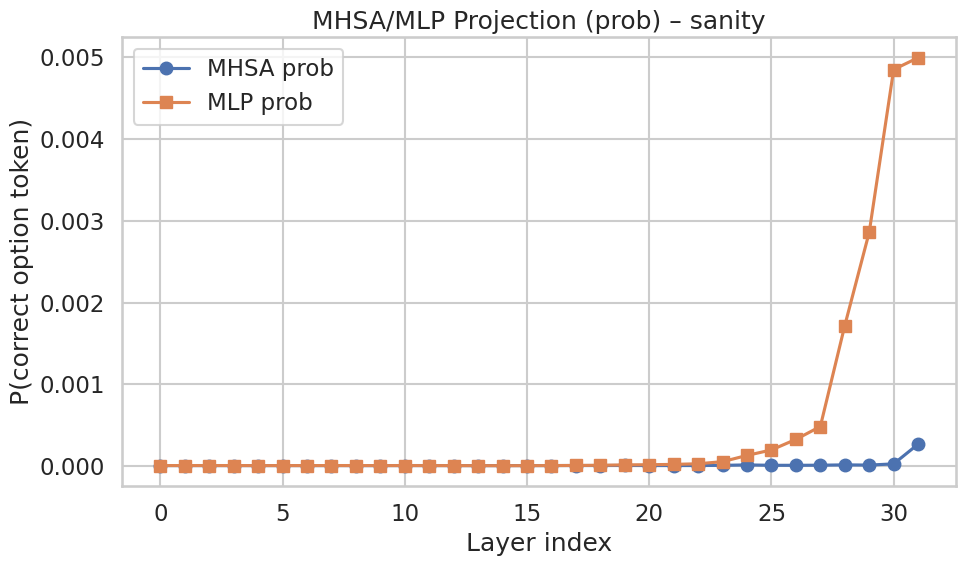

In [ ]:
    sns.set_theme(style="whitegrid", context="talk")

    # 1) 概率版
    plt.figure(figsize=(10, 6))
    plt.plot(df["layer"], df["prob_attn"], label="MHSA prob", marker="o")
    plt.plot(df["layer"], df["prob_mlp"],  label="MLP prob",  marker="s")
    plt.xlabel("Layer index")
    plt.ylabel("P(correct option token)")
    plt.title("MHSA/MLP Projection (prob) ")
    plt.legend()
    plt.tight_layout()

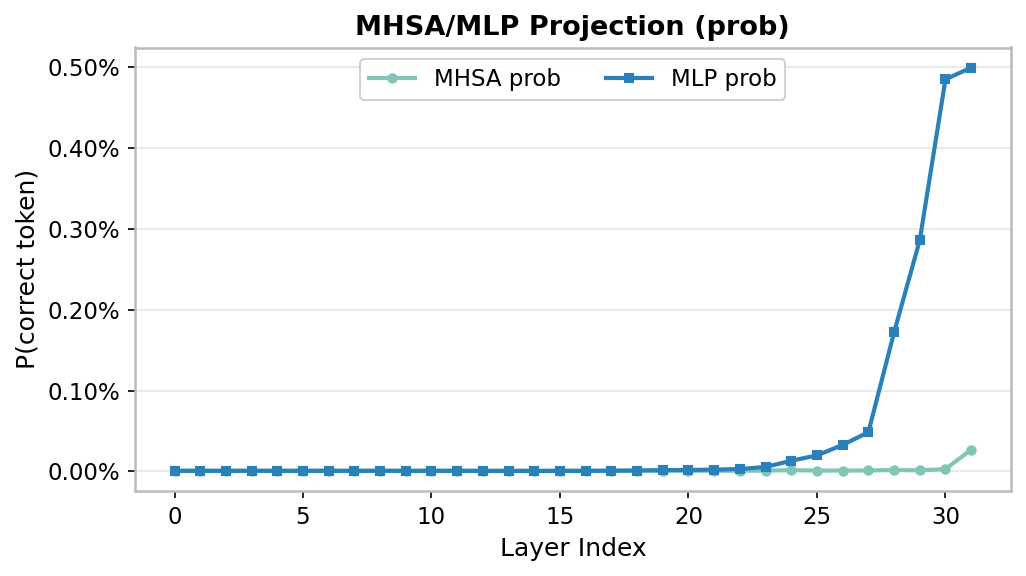

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Color palette (same as target style) ──────────────────────────────────
C1="#c8e1b5"; C2="#80c5b6"; C3="#3db2c0"; C4="#2a80ba"; C5="#24428e"
COLOR_ATTN = C2
COLOR_MLP  = C4

# ── Conference paper global rcParams ──────────────────────────────────────
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "font.size":        12,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   12,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "axes.grid.axis":   "y",
    "grid.color":       "#e5e5e5",
    "grid.linewidth":   0.8,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  11,
    "legend.frameon":   False,
    "figure.dpi":       150,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
})

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(df["layer"], df["prob_attn"], label="MHSA prob",
        color=COLOR_ATTN, marker="o", markersize=4, linewidth=2, zorder=3)
ax.plot(df["layer"], df["prob_mlp"],  label="MLP prob",
        color=COLOR_MLP,  marker="s", markersize=4, linewidth=2, zorder=3)

# Visible box frame on all four sides
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("#BBBBBB")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
ax.set_xlabel("Layer Index")
ax.set_ylabel("P(correct token)")
ax.set_title("MHSA/MLP Projection (prob)")
ax.legend(loc="upper center", frameon=True, framealpha=0.9,
          edgecolor="#CCCCCC", ncol=2)

fig.tight_layout()
plt.show()

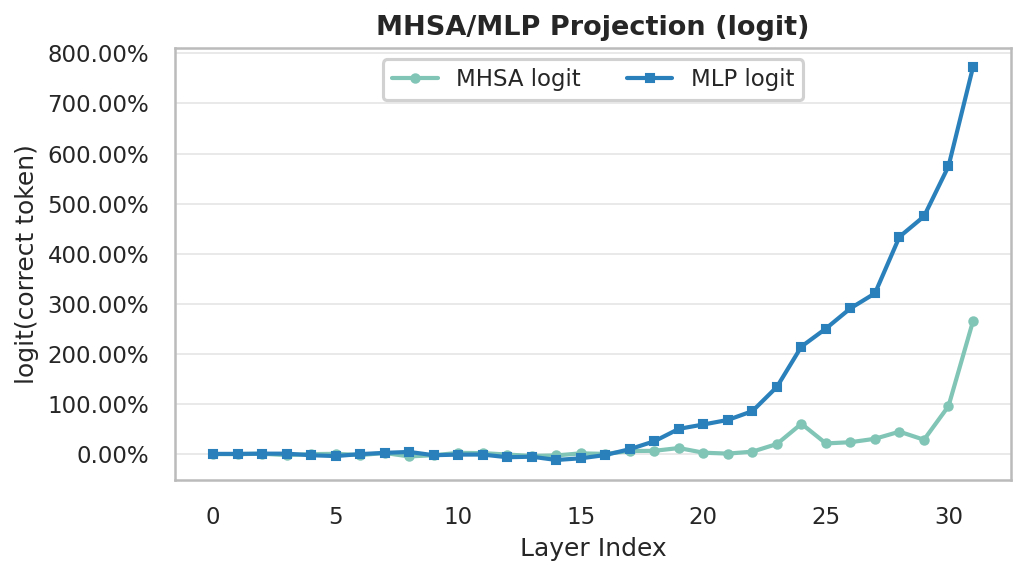

In [ ]:
# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(df["layer"], df["logit_attn"], label="MHSA logit",
        color=COLOR_ATTN, marker="o", markersize=4, linewidth=2, zorder=3)
ax.plot(df["layer"], df["logit_mlp"],  label="MLP logit",
        color=COLOR_MLP,  marker="s", markersize=4, linewidth=2, zorder=3)

# Visible box frame on all four sides
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("#BBBBBB")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
ax.set_xlabel("Layer Index")
ax.set_ylabel("logit(correct token)")
ax.set_title("MHSA/MLP Projection (logit)")
ax.legend(loc="upper center", frameon=True, framealpha=0.9,
          edgecolor="#CCCCCC", ncol=2)

fig.tight_layout()
plt.show()

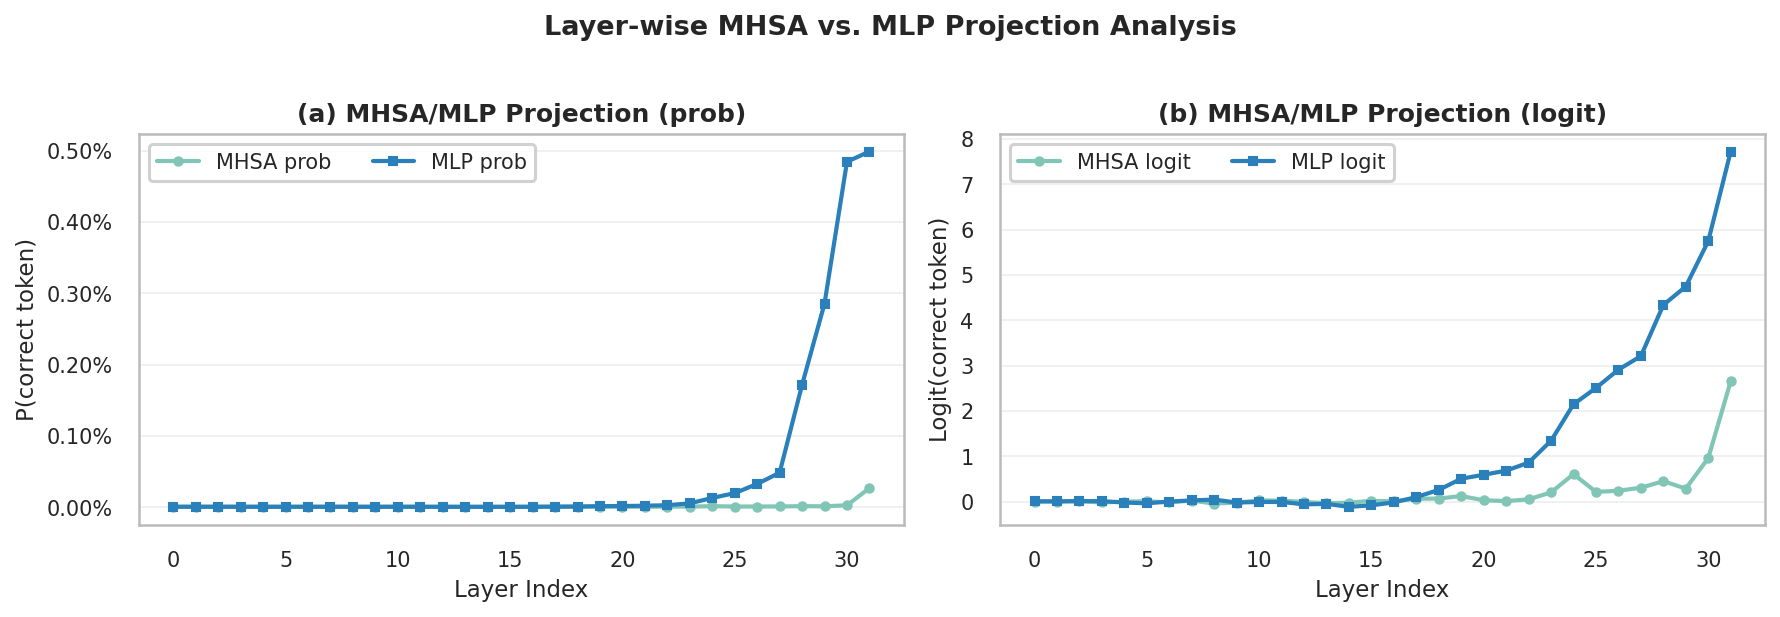

In [ ]:
plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "font.size":       11,
    "axes.titlesize":  12,
    "axes.labelsize":  11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth":  1.2,
    "axes.edgecolor":  "#BBBBBB",
    "axes.grid":       True,
    "grid.color":      "#EEEEEE",
    "grid.linewidth":  0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "figure.dpi":      150,
})

def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_edgecolor("#BBBBBB")

# ── 1×2 combined figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── (a) Prob ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df["layer"], df["prob_attn"], label="MHSA prob",
        color=COLOR_ATTN, marker="o", markersize=4, linewidth=2, zorder=3)
ax.plot(df["layer"], df["prob_mlp"],  label="MLP prob",
        color=COLOR_MLP,  marker="s", markersize=4, linewidth=2, zorder=3)
style_ax(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
ax.set_xlabel("Layer Index")
ax.set_ylabel("P(correct token)")
ax.set_title("(a) MHSA/MLP Projection (prob)")
ax.legend(loc="upper left", frameon=True, framealpha=0.9,
          edgecolor="#CCCCCC", ncol=2)

# ── (b) Logit ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df["layer"], df["logit_attn"], label="MHSA logit",
        color=COLOR_ATTN, marker="o", markersize=4, linewidth=2, zorder=3)
ax.plot(df["layer"], df["logit_mlp"],  label="MLP logit",
        color=COLOR_MLP,  marker="s", markersize=4, linewidth=2, zorder=3)
style_ax(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))
ax.set_xlabel("Layer Index")
ax.set_ylabel("Logit(correct token)")
ax.set_title("(b) MHSA/MLP Projection (logit)")
ax.legend(loc="upper left", frameon=True, framealpha=0.9,
          edgecolor="#CCCCCC", ncol=2)

fig.suptitle("Layer-wise MHSA vs. MLP Projection Analysis",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

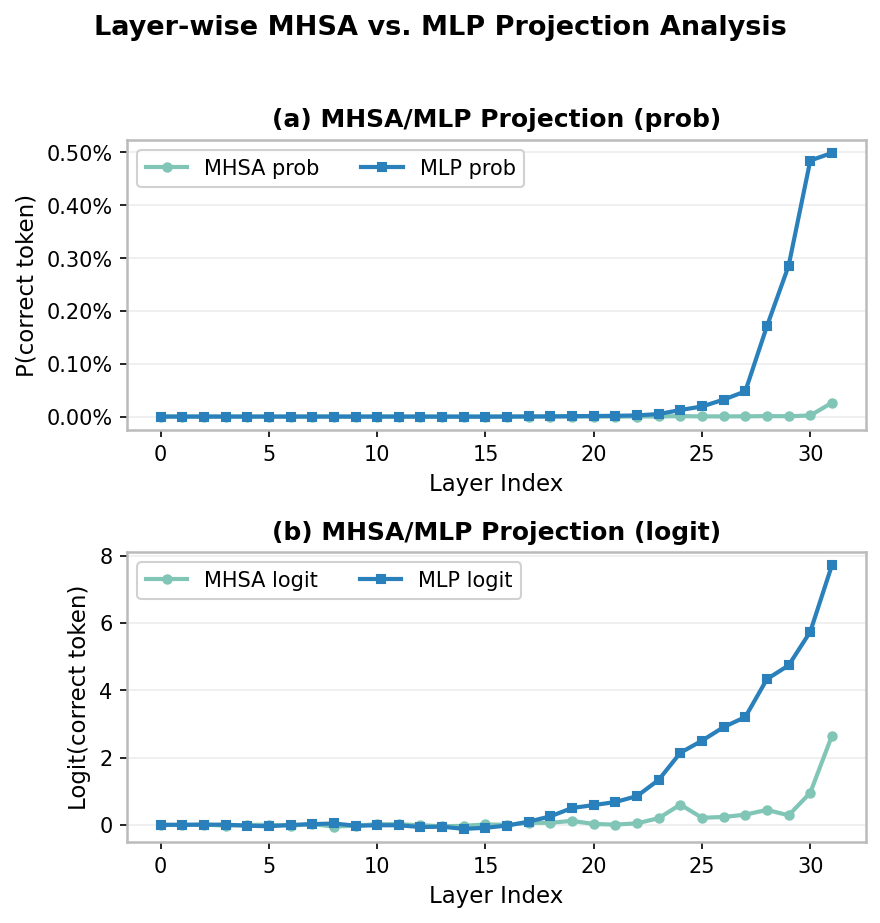

In [ ]:
plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "font.size":       11,
    "axes.titlesize":  12,
    "axes.labelsize":  11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth":  1.2,
    "axes.edgecolor":  "#BBBBBB",
    "axes.grid":       True,
    "grid.color":      "#EEEEEE",
    "grid.linewidth":  0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "figure.dpi":      150,
})

def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_edgecolor("#BBBBBB")

# ── 1×2 combined figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(6,6))

# ── (a) Prob ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df["layer"], df["prob_attn"], label="MHSA prob",
        color=COLOR_ATTN, marker="o", markersize=4, linewidth=2, zorder=3)
ax.plot(df["layer"], df["prob_mlp"],  label="MLP prob",
        color=COLOR_MLP,  marker="s", markersize=4, linewidth=2, zorder=3)
style_ax(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}"))
ax.set_xlabel("Layer Index")
ax.set_ylabel("P(correct token)")
ax.set_title("(a) MHSA/MLP Projection (prob)")
ax.legend(loc="upper left", frameon=True, framealpha=0.9,
          edgecolor="#CCCCCC", ncol=2)

# ── (b) Logit ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df["layer"], df["logit_attn"], label="MHSA logit",
        color=COLOR_ATTN, marker="o", markersize=4, linewidth=2, zorder=3)
ax.plot(df["layer"], df["logit_mlp"],  label="MLP logit",
        color=COLOR_MLP,  marker="s", markersize=4, linewidth=2, zorder=3)
style_ax(ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))
ax.set_xlabel("Layer Index")
ax.set_ylabel("Logit(correct token)")
ax.set_title("(b) MHSA/MLP Projection (logit)")
ax.legend(loc="upper left", frameon=True, framealpha=0.9,
          edgecolor="#CCCCCC", ncol=2)

fig.suptitle("Layer-wise MHSA vs. MLP Projection Analysis",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()